# Lezione 27 — Il grafo delle memorie

**Come si usa questo notebook.** Come sempre. Prerequisito: Lezione 26
(entita' estratte, mappa entita'-memorie, co-occorrenze). Oggi quei dati
grezzi diventano un **grafo navigabile**: nodi e archi che permettono
domande impossibili con una tabella piatta, come "quali altre memorie
sono collegate a questa tramite un'entita' condivisa?".

**Cosa saprai fare alla fine:** costruire un grafo bipartito
memoria-entita' con `networkx`, interrogarlo per trovare memorie
correlate a piu' salti, e visualizzarlo.

## Parte 1 — Teoria: nodi, archi, e perche' un grafo (non solo una tabella)

Un **grafo** e' fatto di **nodi** (qui: memorie ed entita') e **archi**
(qui: "questa memoria menziona questa entita'"). E' **bipartito**: ci sono
due tipi di nodo (memoria, entita'), e gli archi collegano sempre un nodo
di un tipo a un nodo dell'altro tipo, mai due memorie direttamente tra
loro o due entita' direttamente tra loro.

Perche' non basta la tabella della Lezione 26 (`entita' -> lista di
memory_id`)? Perche' una tabella risponde bene a una domanda
("quali memorie menzionano Lucia?") ma non a domande a **piu' salti**:
"quali *altre* memorie condividono un'entita' con *questa* memoria
specifica?" richiede di attraversare memoria -> entita' -> altre memorie
— un percorso di due archi nel grafo, non un singolo lookup in tabella.
Questo e' esattamente cio' che una libreria per grafi come `networkx`
rende diretto: `G.neighbors(nodo)` restituisce i vicini a un salto,
componibile per attraversare piu' salti.

Due concetti che userai subito:

- **grado** di un nodo — quanti archi ha. Il grado di un'entita' e'
  quante memorie la menzionano (la stessa informazione della Lezione 26,
  letta come proprieta' del grafo).
- **vicini a 2 salti** — partendo da una memoria, i suoi vicini diretti
  sono le entita' che menziona; i vicini *dei suoi vicini* sono le altre
  memorie che menzionano le stesse entita'. E' la definizione operativa
  di "memoria correlata" che useremo nel progetto.

In [1]:
import networkx as nx

G_demo = nx.Graph()
G_demo.add_edge('mem_a', 'Lucia')
G_demo.add_edge('mem_a', 'Bologna')
G_demo.add_edge('mem_b', 'Lucia')
G_demo.add_edge('mem_c', 'Bologna')

print('vicini diretti di mem_a:', list(G_demo.neighbors('mem_a')))
print('grado di Lucia:', G_demo.degree('Lucia'))

# memorie a 2 salti da mem_a: passa per le sue entita', poi per le loro memorie
due_salti = set()
for entita in G_demo.neighbors('mem_a'):
    for memoria in G_demo.neighbors(entita):
        if memoria != 'mem_a':
            due_salti.add(memoria)
print('memorie a 2 salti da mem_a:', due_salti)

vicini diretti di mem_a: ['Lucia', 'Bologna']
grado di Lucia: 2
memorie a 2 salti da mem_a: {'mem_b', 'mem_c'}


Leggi l'output: `mem_a` menziona `Lucia` e `Bologna` (vicini diretti,
1 salto). A 2 salti si trovano `mem_b` (condivide `Lucia` con `mem_a`) e
`mem_c` (condivide `Bologna`) — memorie che `mem_a` non menziona
direttamente, ma con cui condivide un'entita'. Questo e' esattamente il
meccanismo di "memorie correlate" che costruiremo sul dataset vero.

## Parte 2 — Esercizio guidato

Il tuo compito: aggiungi al grafo `G_demo` un nuovo arco `('mem_d',
'Bologna')` e verifica che ora i vicini a 2 salti di `mem_a` includano
**sia** `mem_c` **sia** `mem_d` (entrambe condividono `Bologna` con
`mem_a`).

In [2]:
# Scrivi qui: G_demo.add_edge('mem_d', 'Bologna'), poi ricalcola i vicini
# a 2 salti di mem_a e verifica che includano mem_c e mem_d.

pass

### Soluzione spiegata

Aggiungere l'arco `('mem_d', 'Bologna')` rende `mem_d` un vicino di
`Bologna`; poiche' `Bologna` e' gia' un vicino diretto di `mem_a`,
`mem_d` entra automaticamente nei vicini a 2 salti — nessun bisogno di
ricalcolare la logica, il grafo aggiornato la restituisce da solo.

In [3]:
G_demo.add_edge('mem_d', 'Bologna')

due_salti = set()
for entita in G_demo.neighbors('mem_a'):
    for memoria in G_demo.neighbors(entita):
        if memoria != 'mem_a':
            due_salti.add(memoria)
print('memorie a 2 salti da mem_a:', due_salti)
assert due_salti == {'mem_b', 'mem_c', 'mem_d'}

memorie a 2 salti da mem_a: {'mem_b', 'mem_d', 'mem_c'}


## Parte 3 — Il progetto: Memory AI Lab, passo 27 — il grafo di tutto l'archivio

Costruiamo il grafo bipartito su tutto il train set (entita' della
Lezione 26), poi definiamo `memorie_correlate(memory_id)`: la funzione
che la Lezione 28 (retrieval ibrido) usera' come segnale aggiuntivo
accanto alla similarita' per embedding.

In [4]:
import pandas as pd
import re
from pathlib import Path

processed = Path('..') / 'datasets' / 'processed'
train = pd.read_csv(processed / 'memory_train.csv')

STOPWORD_MAIUSCOLE = {'The'}


def estrai_entita(testo):
    candidate = re.findall(r'\b[A-Z][a-zA-Z]*\b', str(testo))
    return [c for c in candidate if c not in STOPWORD_MAIUSCOLE]


train['entita'] = train['text'].apply(estrai_entita)

G = nx.Graph()
for _, riga in train.iterrows():
    G.add_node(riga['memory_id'], tipo='memoria')
    for entita in riga['entita']:
        G.add_node(entita, tipo='entita')
        G.add_edge(riga['memory_id'], entita)

nodi_memoria = sum(1 for _, d in G.nodes(data=True) if d['tipo'] == 'memoria')
nodi_entita = sum(1 for _, d in G.nodes(data=True) if d['tipo'] == 'entita')
print(f'nodi: {G.number_of_nodes()} ({nodi_memoria} memorie, {nodi_entita} entita\')')
print(f'archi: {G.number_of_edges()}')

entita_per_grado = sorted(
    [(n, G.degree(n)) for n, d in G.nodes(data=True) if d['tipo'] == 'entita'],
    key=lambda coppia: -coppia[1])
print("entita' piu' connesse:", entita_per_grado[:5])

nodi: 227 (213 memorie, 14 entita')
archi: 241
entita' piu' connesse: [('Lucia', 28), ('Giorgio', 23), ('Glasgow', 22), ('Sara', 22), ('Elena', 19)]


In [5]:
def memorie_correlate(memory_id, grafo=G):
    correlate = set()
    for entita in grafo.neighbors(memory_id):
        for memoria in grafo.neighbors(entita):
            if memoria != memory_id:
                correlate.add(memoria)
    return correlate


esempio = train.iloc[2]
print(f"memoria: {esempio['memory_id']} - \"{esempio['text']}\" - entita': {esempio['entita']}")

correlate = memorie_correlate(esempio['memory_id'])
print(f'\nmemorie correlate trovate: {len(correlate)}')
for memory_id in list(correlate)[:3]:
    testo = train.loc[train['memory_id'] == memory_id, 'text'].iloc[0]
    print(f'  - {memory_id}: "{testo}"')

memoria: hist_0002 - "Lucia visited Bologna for the weekend." - entita': ['Lucia', 'Bologna']

memorie correlate trovate: 36
  - hist_0200: "Lucia had a long call about la riunione settimanale."
  - hist_0148: "Lucia met a friend in Roma."
  - hist_0195: "Lucia lives near Roma."


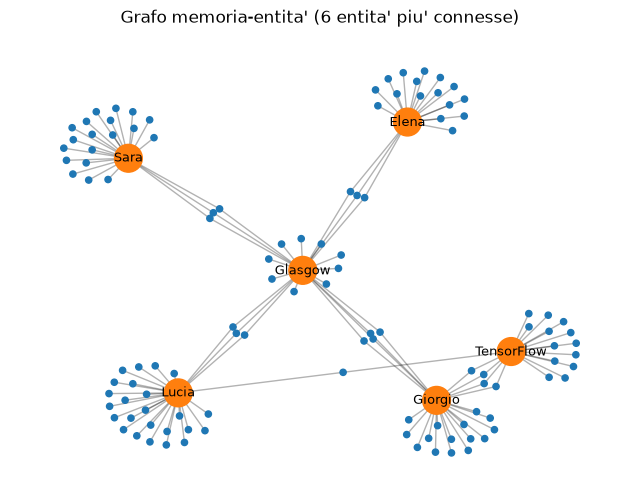

In [6]:
import matplotlib.pyplot as plt

# Sottografo leggibile: solo le entita' e le memorie che le menzionano,
# limitato alle 6 entita' piu' connesse per non affollare il disegno.
entita_top = [n for n, _ in entita_per_grado[:6]]
nodi_sottografo = set(entita_top)
for entita in entita_top:
    nodi_sottografo.update(G.neighbors(entita))
sottografo = G.subgraph(nodi_sottografo)

colori = ['tab:orange' if G.nodes[n]['tipo'] == 'entita' else 'tab:blue'
          for n in sottografo.nodes]
dimensioni = [400 if G.nodes[n]['tipo'] == 'entita' else 20 for n in sottografo.nodes]
etichette = {n: n for n in sottografo.nodes if G.nodes[n]['tipo'] == 'entita'}

fig, ax = plt.subplots(figsize=(8, 6))
posizione = nx.spring_layout(sottografo, seed=42)
nx.draw_networkx_nodes(sottografo, posizione, node_color=colori, node_size=dimensioni, ax=ax)
nx.draw_networkx_edges(sottografo, posizione, alpha=0.3, ax=ax)
nx.draw_networkx_labels(sottografo, posizione, labels=etichette, font_size=9, ax=ax)
ax.set_title("Grafo memoria-entita' (6 entita' piu' connesse)")
ax.axis('off')
plt.show()

Guarda il grafico: le entita' (nodi arancioni, etichettati) sono
circondate da molti piccoli nodi blu (le memorie che le menzionano, senza
etichetta per non affollare il disegno) — le entita' piu' connesse
(`Lucia`, `Giorgio`, `Glasgow`, `Sara`) sono visivamente gli **hub** del
grafo, esattamente come suggerisce il loro grado alto calcolato sopra.
Una memoria che menziona due entita' diverse (es. `Lucia` e `Bologna`)
appare come un piccolo nodo blu con due archi, uno per ciascuna — il
"ponte" che rende possibile il salto a 2 hop di `memorie_correlate`.

## Cosa hai imparato

- Un **grafo bipartito** (memoria-entita') rende esplicito cio' che una
  tabella piatta lascia implicito: le relazioni **a piu' salti** tra
  record che non si menzionano mai direttamente.
- Il **grado** di un nodo entita' e' quante memorie la menzionano —
  stessa informazione della Lezione 26, ora una proprieta' nativa del
  grafo, componibile con altre query.
- `memorie_correlate` (vicini a 2 salti) e' un segnale di correlazione
  **diverso** dalla similarita' per embedding (Lezioni 17-18): trova
  memorie collegate da un fatto condiviso esplicito (la stessa persona,
  lo stesso luogo), non dalla somiglianza del testo nel suo insieme.

## Quiz

1. Perche' il grafo di questa lezione e' descritto come "bipartito", e
   cosa NON puoi fare con un arco diretto in un grafo bipartito
   memoria-entita'?
2. Cosa significa "grado alto" per un nodo entita', e perche' `Lucia` ha
   un grado piu' alto di un'entita' che compare in una sola memoria?
3. In che modo `memorie_correlate` (via grafo) trova connessioni diverse
   da quelle che troverebbe la similarita' coseno (Lezione 18) sugli
   stessi due testi?

<details>
<summary><b>Apri le risposte</b></summary>

1. E' bipartito perche' esistono due tipi di nodo (memoria, entita') e
   ogni arco collega sempre un nodo di un tipo a un nodo dell'altro: non
   esiste (e non avrebbe senso costruire) un arco diretto tra due
   memorie o tra due entita' in questo grafo — quelle relazioni
   emergono solo attraversando due archi (2 salti), non da un arco solo.
2. Il grado e' il numero di archi di un nodo: per un'entita', quante
   memorie diverse la menzionano. `Lucia` ha grado alto perche' compare
   in molte memorie del dataset (28 nell'esecuzione di riferimento);
   un'entita' menzionata una sola volta ha grado 1.
3. La similarita' coseno confronta il **significato complessivo** di due
   testi tramite i loro embedding, anche se non condividono nessuna
   parola esatta. Il grafo trova invece connessioni basate su un
   **fatto esplicito condiviso** (la stessa persona o lo stesso luogo
   nominato), anche tra due memorie il cui embedding potrebbe non essere
   particolarmente simile (es. "Lucia ha visitato Bologna" e "Lucia ha
   avuto una chiamata sul colloquio" parlano di cose diverse, ma
   condividono la persona).
</details>

## Fonti

- NetworkX, documentazione ufficiale, `Graph`:
  https://networkx.org/documentation/stable/reference/classes/graph.html
- NetworkX, documentazione ufficiale, `spring_layout`:
  https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html

## Prossima lezione

Due segnali di correlazione ora esistono in parallelo: similarita' per
embedding (Lezioni 17-18) e correlazione via grafo (oggi). La prossima
lezione li combina, insieme a recency e importanza (Lezioni 24-25), in un
unico **retrieval ibrido**.